In [1]:
!pip install scikit-learn-extra scikit-fuzzy

  Using cached scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
import skfuzzy as fuzz

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


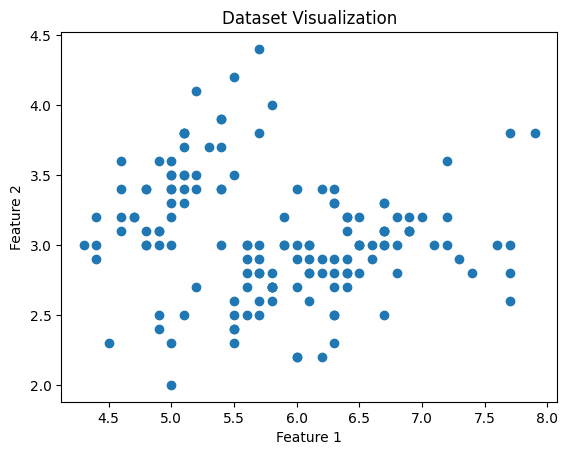

In [4]:
plt.scatter(X[:,0], X[:,1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset Visualization")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X)

kmeans_labels = kmeans.labels_

centroids = kmeans.cluster_centers_

print("Centroids:")
print(centroids)

Centroids:
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


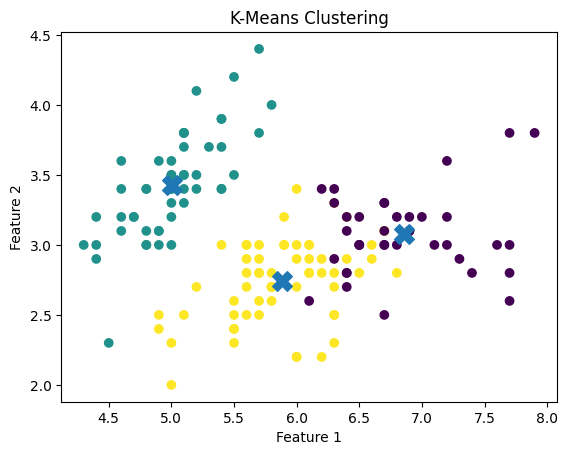

In [6]:
plt.scatter(X[:,0], X[:,1], c=kmeans_labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [7]:
kmedoids = KMedoids(n_clusters=3, random_state=42)

kmedoids.fit(X)

kmedoids_labels = kmedoids.labels_

medoids = kmedoids.cluster_centers_

print("Medoids:")
print(medoids)

Medoids:
[[6.5 3.  5.2 2. ]
 [5.7 2.8 4.1 1.3]
 [5.  3.4 1.5 0.2]]


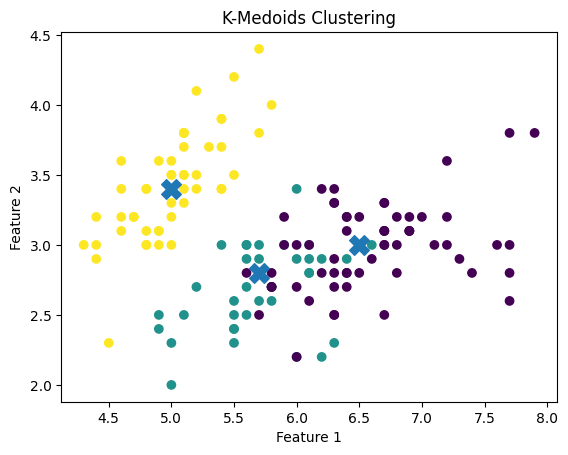

In [8]:
plt.scatter(X[:,0], X[:,1], c=kmedoids_labels)
plt.scatter(medoids[:,0], medoids[:,1], marker='X', s=200)
plt.title("K-Medoids Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [9]:
X_transposed = X.T

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_transposed,
    c=3,
    m=2,
    error=0.005,
    maxiter=1000
)

In [10]:
fuzzy_labels = np.argmax(u, axis=0)

print(fuzzy_labels[:10])

[0 0 0 0 0 0 0 0 0 0]


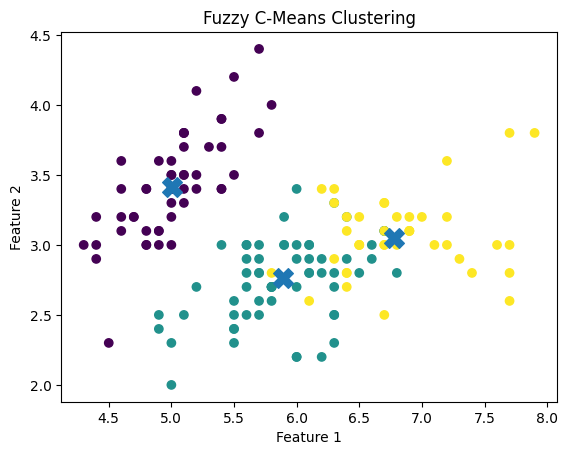

In [11]:
plt.scatter(X[:,0], X[:,1], c=fuzzy_labels)
plt.scatter(cntr[:,0], cntr[:,1], marker='X', s=200)
plt.title("Fuzzy C-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [12]:
results = pd.DataFrame({
    "KMeans": kmeans_labels,
    "KMedoids": kmedoids_labels,
    "FuzzyCMeans": fuzzy_labels
})

results.head()

,KMeans,KMedoids,FuzzyCMeans
0,1,2,0
1,1,2,0
2,1,2,0
3,1,2,0
4,1,2,0
